# 09 — 関節ハイブリッド指令とHardware

## 目的
WBC出力をモータへ渡す最後の式と、Gazebo/Unitreeの共通interfaceを理解する。

実装対応:
- `legged_common/.../HybridJointInterface.h`
- [`UnitreeHW.cpp`](https://github.com/qiayuanliao/legged_control/tree/a7f381c0367e98e31c01336e678eef47e304d40d/legged_unitree_hw/src/UnitreeHW.cpp)
- [`LeggedHWSim.cpp`](https://github.com/qiayuanliao/legged_control/tree/a7f381c0367e98e31c01336e678eef47e304d40d/legged_gazebo/src/LeggedHWSim.cpp)


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "pyproject.toml").exists():
        ROOT = candidate
        break

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True})
print("repository:", ROOT)


repository: /home/takuya/work/mpc_dog


12関節それぞれへ
\[
\tau_\mathrm{cmd}=\tau_\mathrm{WBC}
+K_p(q^*-q)+K_d(\dot q^*-\dot q).
\]
既定は \(K_p=0,\ K_d=3\) なので
\[
\tau_\mathrm{cmd}=\tau_\mathrm{WBC}+3(\dot q^*-\dot q).
\]

`setCommand`引数順は `(q*, dq*, Kp, Kd, ff)`。
実機はUnitree LowCmdへ、Gazeboはplugin内で同じ式を計算してeffortへ渡す。


In [2]:
def hybrid_torque(q, dq, q_des, dq_des, tau_ff, kp=0.0, kd=3.0):
    return tau_ff + kp*(q_des-q) + kd*(dq_des-dq)

q = np.array([0.2, 0.7, -1.4])
dq = np.array([0.1, -0.2, 0.3])
q_des = np.array([0.0, 0.8, -1.5])
dq_des = np.zeros(3)
tau_ff = np.array([2.0, -5.0, 8.0])
print("Kp=0:", hybrid_torque(q,dq,q_des,dq_des,tau_ff))
print("Kp=20:", hybrid_torque(q,dq,q_des,dq_des,tau_ff,kp=20))
print("位置誤差はKp=0なら直接torqueへ入らない")


Kp=0: [ 1.7 -4.4  7.1]
Kp=20: [-2.3 -2.4  5.1]
位置誤差はKp=0なら直接torqueへ入らない


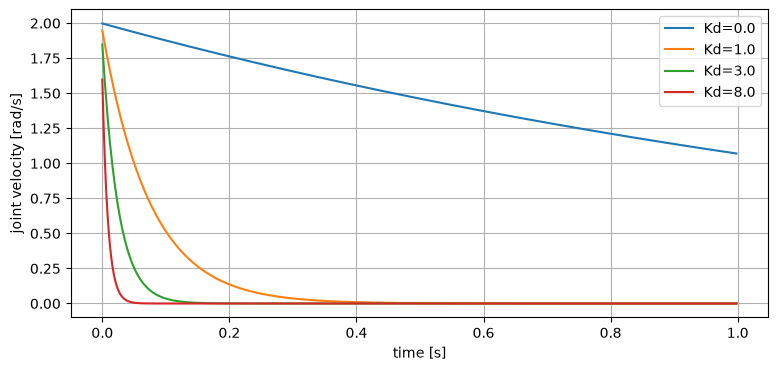

In [3]:
# 1関節の簡易慣性モデルでKdの効果を見る（実機同定モデルではない）。
def simulate_joint(kd, dt=0.002, duration=1.0):
    inertia, damping = 0.08, 0.05
    q, dq, dq_des, tau_ff = 0.0, 2.0, 0.0, 0.0
    out = []
    for k in range(int(duration/dt)):
        tau = tau_ff + kd*(dq_des-dq)
        tau = np.clip(tau, -33.5, 33.5)
        ddq = (tau-damping*dq)/inertia
        dq += dt*ddq; q += dt*dq
        out.append((k*dt, q, dq, tau))
    return np.asarray(out)

for kd in [0.0, 1.0, 3.0, 8.0]:
    h = simulate_joint(kd)
    plt.plot(h[:,0], h[:,2], label=f"Kd={kd}")
plt.xlabel("time [s]"); plt.ylabel("joint velocity [rad/s]")
plt.legend(); plt.show()


## 安全境界
- A1 torque limitは各関節33.5 N m。
- Unitree側はposition limitとpower protectionを適用する。
- controller未接続時、実機readはffと目標速度を0、Kd=3へ戻してdampingを残す。
- `SafetyChecker`は実装上rollが±π/2を超えるかを見るが、pitch・torque・temperatureを
  網羅する安全監視ではない。

### 変更課題
Kpを追加するとWBCのforce controlと位置springが競合しうる。
実機変更はsimの見た目ではなく、passivity/遅延、torque/current limit、接触衝撃、
joint別inertia、停止時挙動を先に評価する。


## 章固有の背景
                WBC torqueは最後に位置・速度feedbackと合成され、simulationと実機のhardware interfaceへ渡る。

                ## 章固有の目的
                setCommandの5値と実際のtorque式、limit/protection、Gazebo/Unitree分岐を追う。

                ## この章のASCIIデータフロー
                ```text
                tau_WBC,q*,dq* -> HybridJointHandle::setCommand
 -> tau_ff+Kp(q*-q)+Kd(dq*-dq) -> limit/protection
 -> Gazebo effort OR Unitree LowCmd OR project MuJoCo ctrl
                ```

                ## 上流C++ / faithful pseudocode と数式の行対応
                ```cpp
                // external/legged_control/legged_controllers/src/LeggedController.cpp
handle.setCommand(qDes,dqDes,0.0,3.0,tauWbc); // [q*,dq*,Kp,Kd,ff]
// external/legged_control/legged_gazebo/src/LeggedHWSim.cpp
tau = ff + kp*(qDes-q) + kd*(dqDes-dq);       // hybrid equation
// external/legged_control/legged_unitree_hw/src/UnitreeHW.cpp
lowCmd.motorCmd[i] = command;                 // 実機transport/protection境界
// src/legged_control_mujoco/adapter.py::hybrid_command
return clip(tau, -33.5, 33.5);                // project adapter境界
                ```

                **事実のラベル**: `external/legged_control/` の記述はcommit
                `a7f381c0367e98e31c01336e678eef47e304d40d` の上流実装事実。数式展開はそのinterfaceを説明する理論。
                `src/legged_control_mujoco/` に言及した行はproject所有adapterの実装であり、
                ROS1/OCS2 SQP原実装とは同一ではない。

                ## 章固有の結論
                既定Kp=0,Kd=3なのでposition errorは直接torqueへ入らない。adapterも同式と33.5 N m clipを使うがUnitree通信ではない。
